In [1]:
from pathlib import Path
import numpy as np
import torch
import torch_directml
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset
import os
import time
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
logs_path = Path("logs")
models_path = Path("models")
confusion_matrices_path = Path("confusion_matrices")

os.makedirs(logs_path, exist_ok=True)
os.makedirs(models_path, exist_ok=True)
os.makedirs(confusion_matrices_path, exist_ok=True)

device = torch_directml.device()
device

device(type='privateuseone', index=0)

### Reading the data from the file

In [3]:
sentences_file = open(Path.cwd() / "FinancialPhraseBank-v1.0" / "Sentences_50Agree.txt")
raw_sentences = sentences_file.read()

sentences_list_with_sentiments = raw_sentences.split("\n")[:-1]

### Splitting the raw text into the actual text and labels

In [4]:
sentences_list = []
labels = []
sentiment_dictionary = {"negative": 2, "neutral": 0, "positive": 1}

for sentence in sentences_list_with_sentiments:
    text, sentiment = sentence.rsplit("@", 1)
    sentences_list.append(text)
    labels.append(sentiment_dictionary[sentiment])
labels = np.array(labels)

### Creating Train/Test Split:

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    sentences_list, 
    labels, 
    train_size=0.8, 
    random_state=43, 
    shuffle=True,
    stratify=labels
)

In [6]:
model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_encodings = tokenizer(X_train, padding="max_length", truncation=True, max_length=80)
test_encodings = tokenizer(X_test, padding="max_length", truncation=True, max_length=80)

c:\Users\theoheuner\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [7]:
train_dataset = Dataset.from_dict({**train_encodings, "label": y_train})
valiadtion_dataset = Dataset.from_dict({**test_encodings, "label": y_test})

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
valiadtion_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
validation_loader = DataLoader(valiadtion_dataset, batch_size=16)

In [8]:
def train_and_validate(model, model_name, optimizer, train_loader, validation_loader, epochs, device, logs_path, models_path, confusion_matrices_path):
    log_file = logs_path / f"{model_name}_log.csv"
    os.makedirs(logs_path, exist_ok=True)
    
    csv_header = (
        "epoch,train_loss,train_acc,val_loss,val_acc,"
        "val_macro_precision,val_macro_recall,val_macro_f1,"
        "negative_precision,negative_recall,negative_f1,"
        "neutral_precision,neutral_recall,neutral_f1,"
        "positive_precision,positive_recall,positive_f1\n"
    )
    
    with open(log_file, "w") as f:
        f.write(csv_header)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_sentences = 0
        total_sentences = 0
        
        start_time = time.time()
        for batch_idx, batch in enumerate(train_loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            
            optimizer.zero_grad()
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            
            loss = outputs.loss 
            loss.backward()
            
            optimizer.step()
            
            running_loss += loss.item()

            logits = outputs.logits
            _, predicted = logits.max(1)
            
            total_sentences += labels.size(0)
            correct_sentences += predicted.eq(labels).sum().item()

            if (batch_idx + 1) % 50 == 0:
                batch_acc = 100. * correct_sentences / total_sentences
                avg_loss = running_loss / (batch_idx + 1)
                print(f"Epoch [{epoch+1}/{epochs}] | Batch [{batch_idx+1}/{len(train_loader)}] | "
                      f"Loss: {avg_loss:.4f} | Accuracy: {batch_acc:.2f}%")
            
        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct_sentences / total_sentences

        model.eval()
        val_loss = 0.0
        val_correct_sentences = 0
        val_total_sentences = 0
        
        all_labels = []
        all_preds = []
        
        with torch.no_grad():
            for batch in validation_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["label"].to(device)
                
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                
                val_loss += outputs.loss.item()
                logits = outputs.logits
                _, predicted = logits.max(1)
                
                val_total_sentences += labels.size(0)
                val_correct_sentences += predicted.eq(labels).sum().item()
                
                all_labels.extend(labels.cpu().numpy().flatten())
                all_preds.extend(predicted.cpu().numpy().flatten())
        
        val_loss_avg = val_loss / len(validation_loader)
        val_acc = 100. * val_correct_sentences / val_total_sentences

        label_ids = [0, 1, 2]
        label_names = ["neutral", "positive", "negative"]

        metrics_dict = classification_report(
            y_true=all_labels, 
            y_pred=all_preds, 
            target_names=label_names, 
            output_dict=True,
            zero_division=0
        )

        macro_precision = metrics_dict["macro avg"]["precision"]
        macro_recall = metrics_dict["macro avg"]["recall"]
        macro_f1 = metrics_dict["macro avg"]["f1-score"]

        negative_precision = metrics_dict["negative"]["precision"]
        negative_recall = metrics_dict["negative"]["recall"]
        negative_f1 = metrics_dict["negative"]["f1-score"]

        neutral_precision = metrics_dict["neutral"]["precision"]
        neutral_recall = metrics_dict["neutral"]["recall"]
        neutral_f1 = metrics_dict["neutral"]["f1-score"]

        positive_precision = metrics_dict["positive"]["precision"]
        positive_recall = metrics_dict["positive"]["recall"]
        positive_f1 = metrics_dict["positive"]["f1-score"]

        with open(log_file, "a") as f:
            f.write(
                f"{epoch+1},{train_loss:.4f},{train_acc:.2f},"
                f"{val_loss_avg:.4f},{val_acc:.2f},"
                f"{macro_precision:.4f},{macro_recall:.4f},{macro_f1:.4f},"
                f"{negative_precision:.4f},{negative_recall:.4f},{negative_f1:.4f},"
                f"{neutral_precision:.4f},{neutral_recall:.4f},{neutral_f1:.4f},"
                f"{positive_precision:.4f},{positive_recall:.4f},{positive_f1:.4f}\n"
            )

        fig, ax = plt.subplots(figsize=(6, 5))
        ConfusionMatrixDisplay.from_predictions(
            y_true=all_labels,
            y_pred=all_preds,
            labels=label_ids,
            display_labels=label_names,
            normalize="true",
            values_format=".2f",
            ax=ax,
            colorbar=True,
            cmap="Blues"
        )
        ax.set_title(f"{model_name} - Epoch {epoch+1}")
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")

        matrix_folder_path = confusion_matrices_path / model_name
        os.makedirs(matrix_folder_path, exist_ok=True)
        plt.savefig(matrix_folder_path / f"{model_name}_cm_epoch_{epoch+1}.png", bbox_inches='tight')
        plt.close(fig)

        model_folder_path = models_path / model_name
        torch.save(model.state_dict(), model_folder_path / f"{model_name}_epoch_{epoch+1}.pth", _use_new_zipfile_serialization=True)

        end_time = time.time()
        print(f"\n--- Epoch {epoch+1}/{epochs} Summary ---")
        print(f"Train Accuracy:    {train_acc:.1f}% | Train Loss: {train_loss:.4f}")
        print(f"Val Accuracy:      {val_acc:.1f}% | Val Loss:   {val_loss_avg:.4f}")
        print(f"Val Macro Metrics: Precision: {macro_precision:.4f} | Recall: {macro_recall:.4f} | F1-Score: {macro_f1:.4f}")
        print(f"Time: {end_time - start_time:.1f}s\n")

In [9]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.001)

In [10]:
train_and_validate(
    model = model, 
    model_name = "finbert_finetuned", 
    optimizer = optimizer, 
    train_loader = train_loader, 
    validation_loader = validation_loader,
    epochs = 5,
    device = device,
    logs_path = logs_path,
    models_path = models_path,
    confusion_matrices_path = confusion_matrices_path
)

c:\Users\theoheuner\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\adamw.py:529: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)


Epoch [1/5] | Batch [50/243] | Loss: 1.2100 | Accuracy: 55.50%
Epoch [1/5] | Batch [100/243] | Loss: 0.8911 | Accuracy: 66.75%
Epoch [1/5] | Batch [150/243] | Loss: 0.7235 | Accuracy: 72.83%
Epoch [1/5] | Batch [200/243] | Loss: 0.6407 | Accuracy: 75.84%

--- Epoch 1/5 Summary ---
Train Accuracy:    77.3% | Train Loss: 0.5969
Val Accuracy:      88.4% | Val Loss:   0.3135
Val Macro Metrics: Precision: 0.8825 | Recall: 0.8584 | F1-Score: 0.8638
Time: 170.2s

Epoch [2/5] | Batch [50/243] | Loss: 0.2593 | Accuracy: 90.38%
Epoch [2/5] | Batch [100/243] | Loss: 0.2624 | Accuracy: 90.62%
Epoch [2/5] | Batch [150/243] | Loss: 0.2530 | Accuracy: 91.04%
Epoch [2/5] | Batch [200/243] | Loss: 0.2490 | Accuracy: 91.19%

--- Epoch 2/5 Summary ---
Train Accuracy:    90.9% | Train Loss: 0.2473
Val Accuracy:      88.0% | Val Loss:   0.3220
Val Macro Metrics: Precision: 0.8643 | Recall: 0.9131 | F1-Score: 0.8846
Time: 163.8s

Epoch [3/5] | Batch [50/243] | Loss: 0.1087 | Accuracy: 96.38%
Epoch [3/5] | B

In [11]:
def plot_training_metrics(log_file_path):

    df = pd.read_csv(log_file_path)
    epochs = df["epoch"]
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True)
    fig.suptitle(f"Sentiment Metrics Over Epochs ({Path(log_file_path).stem})", fontsize=16, fontweight="bold", y=1.02)
    
    classes_config = {
        "Neutral":  {"p": "neutral_precision", "r": "neutral_recall", "f": "neutral_f1", "color": "gray",      "ls": "-",  "marker": "o"},
        "Positive": {"p": "positive_precision", "r": "positive_recall", "f": "positive_f1", "color": "green",     "ls": "-",  "marker": "^"},
        "Negative": {"p": "negative_precision", "r": "negative_recall", "f": "negative_f1", "color": "red",       "ls": "-",  "marker": "s"},
        "Macro Avg":{"p": "val_macro_precision", "r": "val_macro_recall", "f": "val_macro_f1", "color": "blue", "ls": "--", "marker": "x"}
    }
    
    ax_p = axes[0]
    for label, cfg in classes_config.items():
        ax_p.plot(epochs, df[cfg["p"]], label=label, color=cfg["color"], linestyle=cfg["ls"], marker=cfg["marker"], linewidth=2)
    ax_p.set_title("Precision", fontsize=13, fontweight="bold")
    ax_p.set_ylabel("Score Value", fontsize=11)
    ax_p.set_xlabel("Epoch", fontsize=11)
    ax_p.grid(True, linestyle=":", alpha=0.6)
    ax_p.legend(loc="lower right")
    
    ax_r = axes[1]
    for label, cfg in classes_config.items():
        ax_r.plot(epochs, df[cfg["r"]], label=label, color=cfg["color"], linestyle=cfg["ls"], marker=cfg["marker"], linewidth=2)
    ax_r.set_title("Recall", fontsize=13, fontweight="bold")
    ax_r.set_xlabel("Epoch", fontsize=11)
    ax_r.grid(True, linestyle=":", alpha=0.6)
    ax_r.legend(loc="lower right")
    
    
    ax_f = axes[2]
    for label, cfg in classes_config.items():
        ax_f.plot(epochs, df[cfg["f"]], label=label, color=cfg["color"], linestyle=cfg["ls"], marker=cfg["marker"], linewidth=2)
    ax_f.set_title("F1-Score", fontsize=13, fontweight="bold")
    ax_f.set_xlabel("Epoch", fontsize=11)
    ax_f.grid(True, linestyle=":", alpha=0.6)
    ax_f.legend(loc="lower right")
    
    plt.xticks(epochs)
    
    plt.tight_layout()
    plt.show()

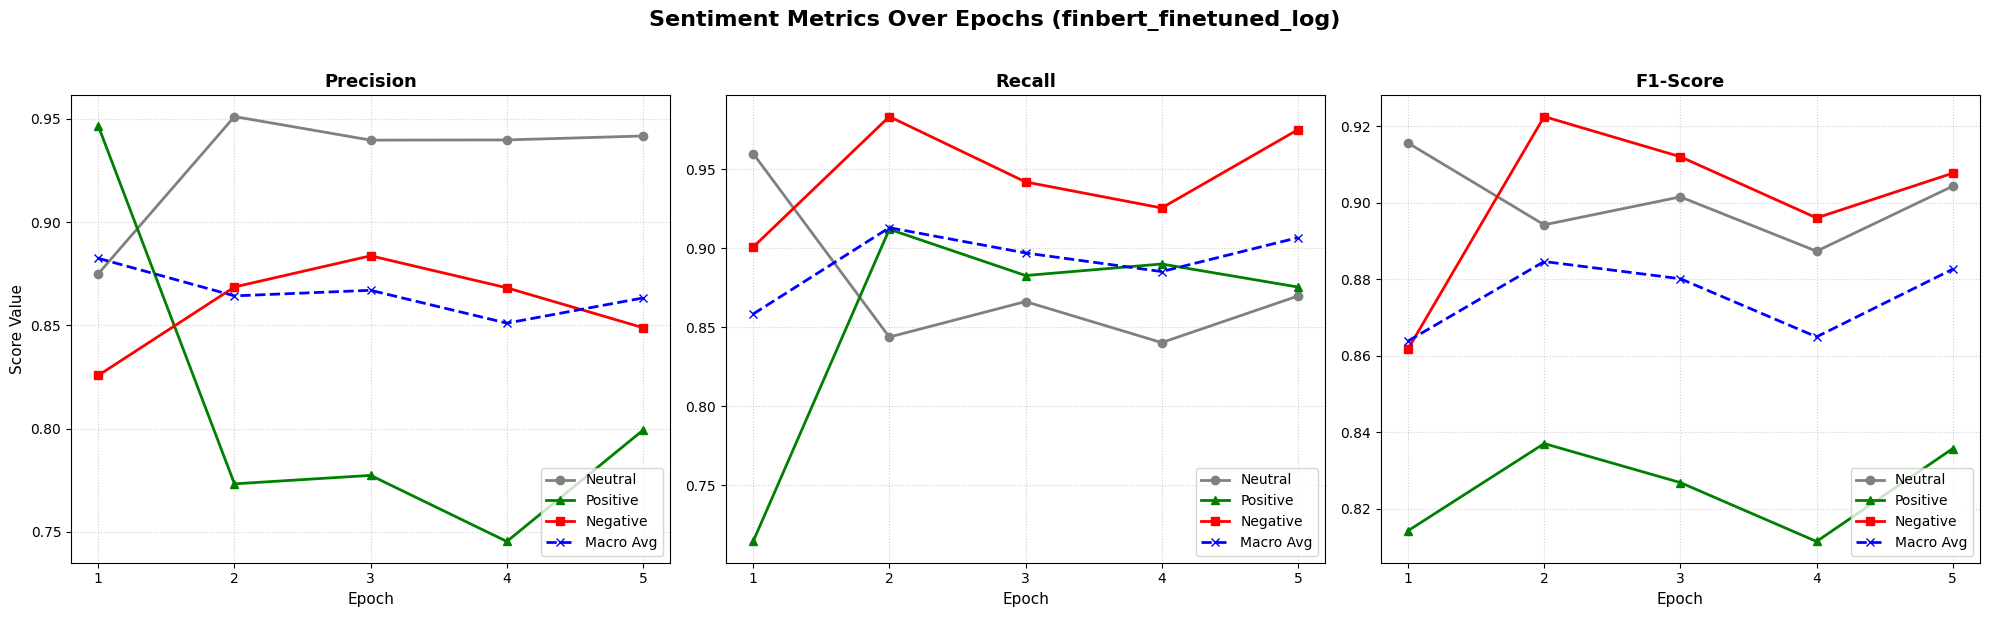

In [12]:
plot_training_metrics(logs_path / "finbert_finetuned_log.csv")